In [98]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import sys
sys.path.insert(1, '../src/')
import gempyModelBuilder as gpmb

def generate_random_values(input_csv, output_csv, stddev_flag=False, z_score=None, **kwargs):
    
    #Keyword Args assingment
    #self.data_path = kwargs.get('data_path')
    #self.project_name = kwargs.get('model_name')  # This is the project name
    variable_list = kwargs.get('variable_list')
    if variable_list == '':
        variable_list = [X_random, Y_random, Z_random, polarity, formation, azimuth, dip_random]


    # Read the CSV file
    df = pd.read_csv(input_csv)
    
    # Create a list to hold the output data
    output_data = []

    for index, col in df.iterrows():
        # Extract the values from the row
        X, Y, Z, polarity, formation, azimuth, dip = col['X'], col['Y'], col['Z'], col['polarity'], col['formation'], col['azimuth'], col.get('dip', np.nan)
        var_X, var_Y, var_Z, var_dip = col.get('var_X', np.nan), col.get('var_Y', np.nan), col.get('var_Z', np.nan), col.get('var_dip', np.nan)
        
        # If theta is missing, use a default value (e.g., 0) and set the variance to 0 if it is also missing
        if pd.isna(var_dip):
            dip = 0.0
            var_dip = 0.0
        if pd.isna(var_X):
            var_X = 0.0
        if pd.isna(var_Y):
            var_Y = 0.0
        if pd.isna(var_Z):
            var_Z = 0.0

        # Calculate the standard deviations
        std_X = np.sqrt(var_X)
        std_Y = np.sqrt(var_Y)
        std_Z = np.sqrt(var_Z)
        std_dip = np.sqrt(var_dip)
        
        if stddev_flag and z_score is not None:
            # Calculate the value corresponding to the given standard deviation from the normal distribution
            X_random = np.around((X + (z_score * std_X)), decimals=1) #stats.norm.ppf(0.5 + 0.5 * stddev_value, loc=X, scale=std_X)
            Y_random = np.around((Y + (z_score * std_Y)), decimals=1) #stats.norm.ppf(0.5 + 0.5 * stddev_value, loc=Y, scale=std_Y)
            Z_random = np.around((Z + (z_score * std_Z)), decimals=1) #stats.norm.ppf(0.5 + 0.5 * stddev_value, loc=Z, scale=std_Z)
            dip_random = np.around((dip + (z_score * std_dip)), decimals=1) #stats.norm.ppf(0.5 + 0.5 * stddev_value, loc=theta, scale=std_theta)
        else:
            # Generate random values from the normal distribution
            X_random = np.random.normal(loc=X, scale=std_X)
            Y_random = np.random.normal(loc=Y, scale=std_Y)
            Z_random = np.random.normal(loc=Z, scale=std_Z)
            dip_random = np.random.normal(loc=dip, scale=std_dip)
        
        # Append the generated values to the output data
        output_data.append([X_random, Y_random, Z_random, polarity, formation, azimuth, dip_random])

    # Create a DataFrame for the output data
    output_df = pd.DataFrame(output_data, columns=['X', 'Y', 'Z', 'polarity', 'formation', 'azimuth', 'dip'])
    
    # Write the output DataFrame to a new CSV file
    output_df.to_csv(output_csv, index=False)

# Example usage:
# generate_random_values('input.csv', 'output.csv', stddev_flag=True, stddev_value=1.0)
# generate_random_values('input.csv', 'output.csv', stddev_flag=False)


In [170]:
df = pd.read_csv("../data/realsurf.csv")
df.loc[df['formation'] == 'Dulkener'].head()

,Unnamed: 0,X,Y,Z,polarity,formation,azimuth,dip
370,0,213345.369171,375071.620058,3000.0,1,Dulkener,40,64
371,1,213286.759578,375220.808733,3000.0,1,Dulkener,40,64
372,2,213233.477931,375327.372100,3000.0,1,Dulkener,40,64
373,3,213087.586333,375531.248596,3000.0,1,Dulkener,40,64
374,4,212957.835474,375689.812343,3000.0,1,Dulkener,40,64


In [177]:
fault_list = ['Dulkener', 'Tegelen', 'Belfeld']
for fault in fault_list:
    df.loc[df['formation'] == fault,['var_X']] = 10
    df.loc[df['formation'] == fault,['var_Y']] = 10
    df.loc[df['formation'] == fault,['var_Z']] = 10
    df.loc[df['formation'] == fault,['var_dip']] = 60


df.to_csv("../data/surface_var_test.csv", index=False)
df.loc[df['formation'] == 'Dulkener'].head()


,Unnamed: 0,X,Y,Z,polarity,formation,azimuth,dip,var_X,var_Y,var_Z,var_dip
370,0,213345.369171,375071.620058,3000.0,1,Dulkener,40,64,10.0,10.0,10.0,60.0
371,1,213286.759578,375220.808733,3000.0,1,Dulkener,40,64,10.0,10.0,10.0,60.0
372,2,213233.477931,375327.372100,3000.0,1,Dulkener,40,64,10.0,10.0,10.0,60.0
373,3,213087.586333,375531.248596,3000.0,1,Dulkener,40,64,10.0,10.0,10.0,60.0
374,4,212957.835474,375689.812343,3000.0,1,Dulkener,40,64,10.0,10.0,10.0,60.0


In [179]:
z_scores = [-2,-1,0,1,2]
output_names = ['../data/calsurf_z-2.csv','../data/calsurf_z-1.csv', '../data/calsurf_z-0.csv','../data/calsurf_z1.csv','../data/calsurf_z2.csv']
orient_names = ['../data/calori-2.csv','../data/calori-1.csv', '../data/calori0.csv','../data/calori1.csv','../data/calori2.csv']


for z_score, name in zip(z_scores, output_names):
    generate_random_values("../data/surface_var_test.csv", name, stddev_flag=True, z_score=z_score)




In [180]:
cali__2 = pd.read_csv('../data/calsurf_z2.csv')

cali__2.loc[df['formation'] == 'Dulkener'].head()

,X,Y,Z,polarity,formation,azimuth,dip
370,213351.7,375077.9,3006.3,1,Dulkener,40,79.5
371,213293.1,375227.1,3006.3,1,Dulkener,40,79.5
372,213239.8,375333.7,3006.3,1,Dulkener,40,79.5
373,213093.9,375537.6,3006.3,1,Dulkener,40,79.5
374,212964.2,375696.1,3006.3,1,Dulkener,40,79.5


In [181]:

for z_score, name in zip(z_scores, output_names):
    df1 = pd.read_csv(name)
    df2 = df1.sample(100)
    df2.to_csv('../data/calori' + str(z_score) + '.csv')


In [182]:

from gempy_engine.core.data.stack_relation_type import StackRelationType
FAULT = StackRelationType.FAULT
ERODE = StackRelationType.ERODE
ONLAP = StackRelationType.ONLAP

def cali_modeling(orients, surface_points): 

    data_path = '../data/'
    #interfacessurf.to_csv('calsurf_z-2.csv')
    #orientationssurf.to_csv('calsurf_z-2.csv')
    orients = orients
    surface_points = surface_points
    project_name = 'Californie model 5'
    extents = [197000,210000,375000,387000,0,3000]   #[Xmin, Xmax, Ymin, Ymax, Zmin, Zmax]
    formation_map_type = {   "Tegelen_fault": ['Tegelen',  FAULT],
                        "Dulkener_fault": [ 'Dulkener', FAULT],
                        "Befeld_fault" : ['Belfeld' , FAULT],
                        "Cenezoic": ['NSG', ERODE],
                        "Mesozoic" : ['Mesozoic', ONLAP],
                        "Paleozoic" : [ ('Namurian', 'Zeeland') , ERODE]
                        #"Paleozoic Series": ('Top_Carboniferous', 'Top_zeeland')
                    }
    ones = np.ones(9).reshape(3,3)
    zeros = np.zeros(9).reshape(3,3)
    fault_relations = np.vstack((np.hstack((zeros,ones)),np.hstack((zeros,zeros))))

    return gpmb.create_gempy_model(surface_points, orients, extents, formation_map_type, fault_relations, data_path=data_path, refinement=4, project_name=project_name).return_geo_data()


In [123]:
#gpmb.create_gempy_model(surface_points, orients, extents, formation_map_type, fault_relations, data_path=data_path, refinement=2, project_name=project_name).return_3d_plot_inputs()

In [183]:
model2 = gpmb.create_gempy_model(surface_points, orients, extents, formation_map_type, fault_relations, data_path=data_path, refinement=2, project_name=project_name).return_geo_data()

Setting Backend To: AvailableBackends.numpy


In [184]:
models = [model_2, model_1, model_0, model1, model2]

for orients, surface_points, model in zip (orient_names,output_names,models):
    model = cali_modeling(orients, surface_points)


Setting Backend To: AvailableBackends.numpy
Chunking done: 6 chunks
Chunking done: 12 chunks
Chunking done: 10 chunks
Chunking done: 13 chunks
Setting Backend To: AvailableBackends.numpy
Chunking done: 6 chunks
Chunking done: 11 chunks
Chunking done: 10 chunks
Chunking done: 14 chunks
Setting Backend To: AvailableBackends.numpy
Chunking done: 6 chunks
Chunking done: 6 chunks
Chunking done: 12 chunks
Chunking done: 10 chunks
Chunking done: 13 chunks
Setting Backend To: AvailableBackends.numpy
Chunking done: 7 chunks
Chunking done: 12 chunks
Chunking done: 9 chunks
Chunking done: 14 chunks
Setting Backend To: AvailableBackends.numpy
Chunking done: 12 chunks
Chunking done: 10 chunks
Chunking done: 15 chunks


/opt/anaconda3/envs/gp/lib/python3.12/site-packages/gempy_viewer/API/_plot_2d_API.py:174: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


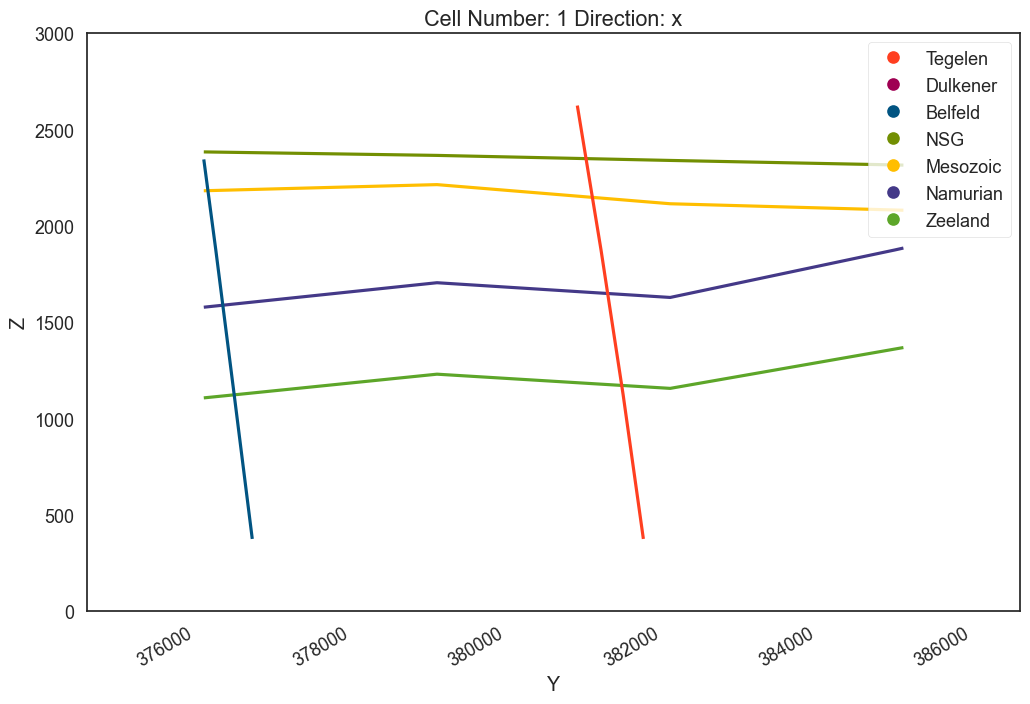

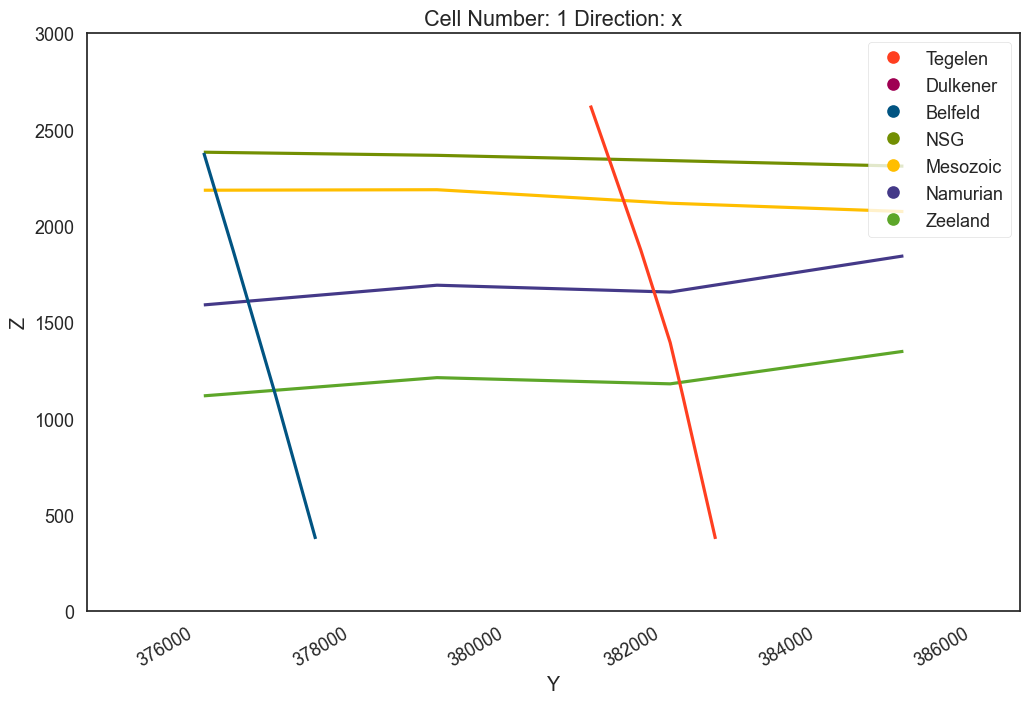

In [185]:


import gempy_viewer as gpv

#type(cali)


gpv.plot_2d(model2, show_data=False, show_boundaries=True,  direction='x', cell_number=1,  show_lith=False, kwargs_plotter={'notebook' : True}, kwargs_pyvista_bounds={})
gpv.plot_2d(model_2, show_data=False, show_boundaries=True,  direction='x', cell_number=1,  show_lith=False, kwargs_plotter={'notebook' : True}, kwargs_pyvista_bounds={})

#gpv.plot_3d()


In [197]:
#gpv.plot_3d(model2, show_data=False, show_boundaries=True, show_lith=False, kwargs_plotter={'notebook' : True}, kwargs_pyvista_bounds={})

edges, centroids = tp.compute_topology(model2)

ModuleNotFoundError: No module named 'gempy_plugins'

: 